In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\dataset\train_set_acute_cardiotoxicity_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())

[11:55:16] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored
[11:55:19] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored
[11:55:25] Warning: ambiguous stereochemistry - zero final chiral volume - at atom 9 ignored


Train DataFrame:
                                              smiles labels  \
0  N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...      0   
1  CO[C@@H](C)CN(CCc1ccc(Cl)cc1)C1CCN(c2nc(N)n[nH...      0   
2  CC(C)(C)NC(=O)n1nc(NCC(=O)NC2CN([C@H]3CC[C@@H]...      1   
3  Cc1ccc2c(-c3nnc(SCCCN4CCc5cc6nc(C(F)(F)F)oc6cc...      1   
4  CC(C)[C@H](N)C(=O)N1CC(c2cc(F)ccc2F)=C[C@H]1c1...      1   

                                          IUPAC name ID  \
0  6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...      
1  1-(5-amino-1H-1,2,4-triazol-3-yl)-N-[2-(4-chlo...      
2  3-[[2-[[1-[4-(1,3-benzodioxol-5-yl)cyclohexyl]...      
3  7-[3-[[4-methyl-5-(2-methylquinolin-5-yl)-1,2,...      
4  (2S)-2-amino-1-[(2S)-4-(2,5-difluorophenyl)-2-...      

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ...   
3  [0, 0, 0, 0, 0, 0, 0, 

In [4]:
train_df

,smiles,labels,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES
0,N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,0,"6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5425815895003938, 1.751943692500183, 1.5141...",N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...
1,CO[C@@H](C)CN(CCc1ccc(Cl)cc1)C1CCN(c2nc(N)n[nH...,0,"1-(5-amino-1H-1,2,4-triazol-3-yl)-N-[2-(4-chlo...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0076031339381548, -0.942507047922774, -1.1...",CO[C@@H](C)CN(CCc1ccc(Cl)cc1)C1CCN(c2nc(N)n[nH...
2,CC(C)(C)NC(=O)n1nc(NCC(=O)NC2CN([C@H]3CC[C@@H]...,1,"3-[[2-[[1-[4-(1,3-benzodioxol-5-yl)cyclohexyl]...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, ...","[2.167322461260175, 2.1562610507333426, 2.3117...",CC(C)(C)NC(=O)n1nc(NCC(=O)NC2CN([C@H]3CC[C@@H]...
3,Cc1ccc2c(-c3nnc(SCCCN4CCc5cc6nc(C(F)(F)F)oc6cc...,1,"7-[3-[[4-methyl-5-(2-methylquinolin-5-yl)-1,2,...",,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.466046382988512, 1.6980347114024283, 1.9209...",Cc1ccc2c(-c3nnc(SCCCN4CCc5cc6nc(C(F)(F)F)oc6cc...
4,CC(C)[C@H](N)C(=O)N1CC(c2cc(F)ccc2F)=C[C@H]1c1...,1,"(2S)-2-amino-1-[(2S)-4-(2,5-difluorophenyl)-2-...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45979299947326313, -0.6380211361669376, -0...",CC(C)[C@H](N)C(=O)N1CC(c2cc(F)ccc2F)=C[C@H]1c1...
...,...,...,...,...,...,...,...,...
8266,CO[C@H]1CC[C@H](Nc2ccn3ncc(-c4cccc(Cl)c4)c3n2)CC1,0,3-(3-chlorophenyl)-N-(4-methoxycyclohexyl)pyra...,,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0396411273617332, -0.7987497649954284, -0....",CO[C@H]1CC[C@H](Nc2ccn3ncc(-c4cccc(Cl)c4)c3n2)CC1
8267,O=C(O)c1cccc(CN2C(=O)/C(=C(\c3ccccc3)c3ccc(Cl)...,0,3-[[(3E)-3-[(4-chlorophenyl)-phenylmethylidene...,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.16178362602246094, 0.5579595926313957, 0.47...",O=C(O)c1cccc(CN2C(=O)/C(=C(\c3ccccc3)c3ccc(Cl)...
8268,COc1ccc2nccc([C@@H](O)CC[C@@H]3CCN(CCSc4ccco4)...,0,"(3R,4R)-1-[2-(furan-2-ylsulfanyl)ethyl]-4-[(3S...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.023720311207888842, -0.11690098555530976, ...",COc1ccc2nccc([C@@H](O)CC[C@@H]3CCN(CCSc4ccco4)...
8269,O=C(O)C1=C[N+](C2CC2)=C2C=C(N3CCNCC3)C(F)=CC2C1=O,0,nan,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5398879830322094, -0.6919301172646921, -0....",O=C(O)C1=C[N+](C2CC2)=C2C=C(N3CCNCC3)C(F)=CC2C1=O


In [5]:
#renaming column
train_df = train_df.rename(columns={'labels': 'Outcome'})

#showing column 
train_df= train_df.sort_values(['Outcome'], ascending=True)
train_df['RowID'] = train_df.index
train_df.head(100)

,smiles,Outcome,IUPAC name,ID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,RowID
0,N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,0,"6-[[[1-[2-[6-[(3S,4R)-4-aminooxolan-3-yl]oxy-3...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5425815895003938, 1.751943692500183, 1.5141...",N[C@@H]1COC[C@H]1Oc1ccc2ncc(F)c(CCC34CCC(NCc5c...,0
4479,CC(C)C(Cn1ccnc1)NC(=O)NC1CCN(Cc2ccn(-c3ccc(C(F...,0,1-(1-imidazol-1-yl-3-methylbutan-2-yl)-3-[1-[[...,,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8217267374698773, 0.5839157687155, 0.743269...",CC(C)C(Cn1ccnc1)NC(=O)NC1CCN(Cc2ccn(-c3ccc(C(F...,4479
4478,Cc1ccc(OC(=O)N(CC(=O)O)Cc2cccc(OCc3nc(-c4ccc(C...,0,"2-[[3-[[2-(4-chlorophenyl)-5-methyl-1,3-oxazol...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9467144649001344, 1.106034233791901, 0.7147...",Cc1ccc(OC(=O)N(CC(=O)O)Cc2cccc(OCc3nc(-c4ccc(C...,4478
4477,CO[C@H]1CC[C@H](N2C(=O)CNc3ncc(-c4ccc(C(C)(C)O...,0,3-[6-(2-hydroxypropan-2-yl)pyridin-3-yl]-5-(4-...,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.26756503893179207, -0.10791615537235065, -...",CO[C@H]1CC[C@H](N2C(=O)CNc3ncc(-c4ccc(C(C)(C)O...,4477
4475,CN1CC[C@H](N(C)C(=O)N2CC(c3cc(F)ccc3F)=C[C@@]2...,0,"(5S)-3-(2,5-difluorophenyl)-N-[(3S,4S)-3-fluor...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6455177736401956, 0.30538603304376793, 0.30...",CN1CC[C@H](N(C)C(=O)N2CC(c3cc(F)ccc3F)=C[C@@]2...,4475
...,...,...,...,...,...,...,...,...,...
4659,NC[C@]1(c2cccc(Cl)c2)CC[C@H](N2CCn3c(nnc3C(F)(...,0,7-[4-(aminomethyl)-4-(3-chlorophenyl)cyclohexy...,,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.33799258985214276, 0.15364223439823624, 0.6...",NC[C@]1(c2cccc(Cl)c2)CC[C@H](N2CCn3c(nnc3C(F)(...,4659
4660,Cc1onc(-c2ccccc2Cl)c1C(=O)N(C)c1ccc(Cl)cc1,0,"3-(2-chlorophenyl)-N-(4-chlorophenyl)-N,5-dime...",,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8826154065078982, -0.6450093374203502, -0....",Cc1onc(-c2ccccc2Cl)c1C(=O)N(C)c1ccc(Cl)cc1,4660
4692,CCc1cc2c(cc1N1CCN(CC3(O)CCOCC3)CC1)C(C)(C)c1[n...,0,9-ethyl-8-[4-[(4-hydroxyoxan-4-yl)methyl]piper...,,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.3892138262515674, 0.8175213534724366, 0.700...",CCc1cc2c(cc1N1CCN(CC3(O)CCOCC3)CC1)C(C)(C)c1[n...,4692
4689,COc1nn(-c2cnccn2)cc1C(=O)Nc1cccc(-c2nncn2C(C)C)n1,0,"3-methoxy-N-[6-(4-propan-2-yl-1,2,4-triazol-3-...",,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.3892138262515674, 0.7905668629235594, 0.561...",COc1nn(-c2cnccn2)cc1C(=O)Nc1cccc(-c2nncn2C(C)C)n1,4689


In [6]:
train_df.keys()

Index(['smiles', 'Outcome', 'IUPAC name', 'ID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'RowID'],
      dtype='object')

Classes                          :  ['0' '1']
Number of cpds in each class     :  [3568, 4703]
Total number of cpds             :  8271
Class mapping:  {0: 0, 1: 1}


{0: 0, 1: 1}

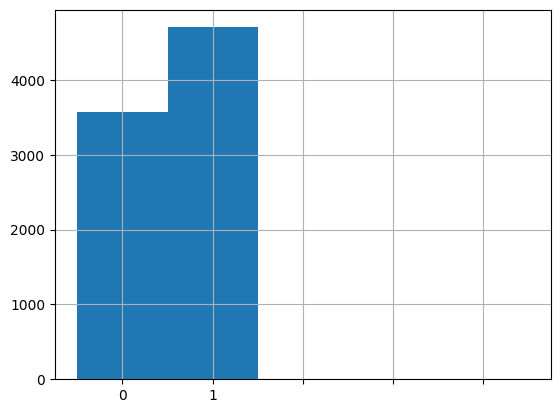

In [7]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(train_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(train_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = train_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [8]:
y= np.int32((S))
x = np.array(list(train_df['Morgan_Descriptors']))

In [9]:
print(x)

[[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [9]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12, x.shape[1] // 10,
        x.shape[1] // 7, x.shape[1] // 5, x.shape[1] // 3
    ],
    "n_estimators": [10, 100, 300],
}


cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Everything else remains the same in your GridSearchCV initialization and fitting
model_rf_morgan = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1)  

# Fit the model
model_rf_morgan.fit(x, y)

# Get the best model
best_model_rf_morgan = model_rf_morgan.best_estimator_

print("Best Params:", model_rf_morgan.best_params_)
print("Best Score :", model_rf_morgan.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits



KeyboardInterrupt


KeyboardInterrupt



In [ ]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_morgan.predict(X_test)
    y_proba = best_model_rf_morgan.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


In [10]:
#SVM
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score


paramgrid = {
    "C": [0.1, 1, 10,15],  # Regularization parameter
    "kernel": ['rbf'],  # Type of the kernel
    "gamma": ['scale', 'auto']  # Kernel coefficient
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with SVC
model_svm_morgan = GridSearchCV(
    estimator=SVC(probability=True), 
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1  
)

# Fit the model
model_svm_morgan.fit(x, y)

# Get the best model
best_model_svm_morgan = model_svm_morgan.best_estimator_

print("Best Params:", model_svm_morgan.best_params_)
print("Best Score :", model_svm_morgan.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
ERROR! Session/line number was not unique in database. History logging moved to new session 897
Best Params: {'C': 15, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.5498167965383363


In [11]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_morgan.predict(X_test)
    y_proba = best_model_svm_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[516 198]
 [185 756]]
Confusion Matrix for Fold 2:
[[522 192]
 [167 773]]
Confusion Matrix for Fold 3:
[[528 186]
 [170 770]]
Confusion Matrix for Fold 4:
[[530 183]
 [181 760]]
Confusion Matrix for Fold 5:
[[527 186]
 [159 782]]
Overall CV Accuracy: 0.7815273784691146
Overall CV AUC: 0.8569644638294219
Overall CV Precision: 0.8025436327999271
Overall CV Recall (Sensitivity): 0.8167144504488209
Overall CV F1 Score: 0.8095490378087515
Overall CV Specificity: 0.7351491508244251
Overall CV PPV (Positive Predictive Value): 0.8025436327999271
Overall CV NPV (Negative Predictive Value): 0.752761715184486
Overall CV CCR (Correct Classification Rate): 0.7759318006366229


In [12]:
#XGB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [3, 5, 7],  # Common choices for tree depth
    "n_estimators": [100, 200],  # Number of trees
    "learning_rate": [0.1, 0.2,0.4]  # Step size shrinkage used to prevent overfitting
}

# Define the cross-validator
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Set up the GridSearchCV with XGBClassifier
model_xgb_morgan = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),  
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1  # Use -1 to use all cores
)

# Fit the model
model_xgb_morgan.fit(x, y)

# Get the best model
best_model_xgb_morgan = model_xgb_morgan.best_estimator_

print("Best Params:", model_xgb_morgan.best_params_)
print("Best Score :", model_xgb_morgan.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:49:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best Score : 0.531274895482829


In [13]:
#XGBOOST
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_morgan.predict(X_test)
    y_proba = best_model_xgb_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:53:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:53:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:158: UserWarning: [20:53:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, Us

Confusion Matrix for Fold 1:
[[493 221]
 [173 768]]
Confusion Matrix for Fold 2:
[[521 193]
 [170 770]]
Confusion Matrix for Fold 3:
[[518 196]
 [160 780]]
Confusion Matrix for Fold 4:
[[512 201]
 [184 757]]
Confusion Matrix for Fold 5:
[[503 210]
 [146 795]]
Overall CV Accuracy: 0.7758449898990637
Overall CV AUC: 0.8560724953293262
Overall CV Precision: 0.791307917673288
Overall CV Recall (Sensitivity): 0.8228796888778348
Overall CV F1 Score: 0.8067244146523592
Overall CV Specificity: 0.7138441351295076
Overall CV PPV (Positive Predictive Value): 0.791307917673288
Overall CV NPV (Negative Predictive Value): 0.7537804967735016
Overall CV CCR (Correct Classification Rate): 0.7683619120036712


In [12]:
# ==============================================================================
# TAHAP 1: GRID SEARCH NEURAL NETWORK (MLP)
# ==============================================================================
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
import pandas as pd
import numpy as np

# --- 1. Persiapan Data ---
if 'x' not in locals():
    raise ValueError("Variabel 'x' dan 'y' belum didefinisikan!")

if isinstance(x, (pd.DataFrame, pd.Series)):
    X_data = x.to_numpy()
else:
    X_data = x

if isinstance(y, (pd.DataFrame, pd.Series)):
    y_data = y.to_numpy()
else:
    y_data = y

# --- 2. Setup Hyperparameter ---
# Neural Network butuh disetting lapisan neuron-nya (Hidden Layers)
# (100,) artinya 1 lapisan dengan 100 neuron
# (100, 50) artinya 2 lapisan: lapisan pertama 100 neuron, kedua 50 neuron
paramgrid_nn = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50)], 
    'activation': ['relu'],           # Fungsi aktivasi standar
    'alpha': [0.0001, 0.01],          # Regularization (mencegah overfitting)
    'learning_rate_init': [0.001, 0.01] # Kecepatan belajar
}

cv_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# --- 3. Grid Search ---
print("Sedang menjalankan Grid Search Neural Network...")
print("Tips: Jika muncul 'ConvergenceWarning', itu normal (artinya butuh iterasi lebih).")

model_nn_morgan = GridSearchCV(
    estimator=MLPClassifier(
        solver='adam',          # Optimizer terbaik untuk data umum
        max_iter=1000,          # Maksimal belajar 1000 kali (epoch)
        early_stopping=True,    # BERHENTI jika akurasi stag (Biar Cepat)
        random_state=24
    ),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv_split,
    verbose=1,
    n_jobs=-1 
)

model_nn_morgan.fit(X_data, y_data)

# Simpan model terbaik
best_model_nn_morgan = model_nn_morgan.best_estimator_

print("\nTraining Selesai!")
print(f"Best Params: {model_nn_morgan.best_params_}")

Sedang menjalankan Grid Search Neural Network...
Tips: Jika muncul 'ConvergenceWarning', itu normal (artinya butuh iterasi lebih).
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Training Selesai!
Best Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}


In [13]:
# ==============================================================================
# TAHAP 2: EVALUASI METRIK NEURAL NETWORK (LENGKAP)
# ==============================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                             precision_score, recall_score, f1_score)
import numpy as np

print("Memulai Evaluasi Detail Neural Network...")

# Pastikan data X dan y dalam bentuk array
# (Menggunakan X_data dan y_data dari Tahap 1)

n_splits = 5
cv_eval = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=24)

# List penampung hasil (Lengkap)
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Loop Evaluasi
for i, (train_index, test_index) in enumerate(cv_eval.split(X_data, y_data)):
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit ulang model terbaik
    best_model_nn_morgan.fit(X_train, y_train)
    
    # Prediksi
    y_pred = best_model_nn_morgan.predict(X_test)
    y_proba = best_model_nn_morgan.predict_proba(X_test)[:, 1]
    
    # Hitung Metrik Dasar
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    
    # Hitung Metrik Lanjutan (Safe Division)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = calculate_ccr(sens, spec)
    
    # Simpan ke list
    sensitivity_scores.append(sens)
    specificities.append(spec)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)
    
    print(f"Fold {i+1} selesai.")

# --- Tampilkan Hasil LENGKAP ---
print("\n" + "="*40)
print("HASIL EVALUASI NEURAL NETWORK (RATA-RATA)")
print("="*40)

for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}:\n{cm}")
    
print("-" * 40)
print(f'Overall CV Accuracy       : {np.mean(accuracies):.4f}')
print(f'Overall CV AUC            : {np.mean(auc_scores):.4f}')
print(f'Overall CV Precision      : {np.mean(precisions):.4f}')
print(f'Overall CV Sensitivity    : {np.mean(sensitivity_scores):.4f}')
print(f'Overall CV Specificity    : {np.mean(specificities):.4f}')
print(f'Overall CV F1 Score       : {np.mean(f1_scores):.4f}')
print(f'Overall CV PPV            : {np.mean(ppvs):.4f}')
print(f'Overall CV NPV            : {np.mean(npvs):.4f}')
print(f'Overall CV CCR            : {np.mean(ccrs):.4f}')
print("="*40)

Memulai Evaluasi Detail Neural Network...
Fold 1 selesai.
Fold 2 selesai.
Fold 3 selesai.
Fold 4 selesai.
Fold 5 selesai.

HASIL EVALUASI NEURAL NETWORK (RATA-RATA)

Confusion Matrix Fold 1:
[[517 197]
 [209 732]]

Confusion Matrix Fold 2:
[[491 223]
 [201 739]]

Confusion Matrix Fold 3:
[[515 199]
 [188 752]]

Confusion Matrix Fold 4:
[[513 200]
 [176 765]]

Confusion Matrix Fold 5:
[[506 207]
 [164 777]]
----------------------------------------
Overall CV Accuracy       : 0.7625
Overall CV AUC            : 0.8397
Overall CV Precision      : 0.7859
Overall CV Sensitivity    : 0.8005
Overall CV Specificity    : 0.7124
Overall CV F1 Score       : 0.7931
Overall CV PPV            : 0.7859
Overall CV NPV            : 0.7308
Overall CV CCR            : 0.7565


In [14]:
# ==============================================================================
# TAHAP 1: GRID SEARCH LIGHTGBM
# ==============================================================================
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score
import pandas as pd
import numpy as np

# --- 1. Persiapan Data (Wajib Array) ---
if 'x' not in locals():
    raise ValueError("Variabel 'x' dan 'y' belum didefinisikan!")

# Konversi ke Numpy Array agar aman
if isinstance(x, (pd.DataFrame, pd.Series)):
    X_data = x.to_numpy()
else:
    X_data = x

if isinstance(y, (pd.DataFrame, pd.Series)):
    y_data = y.to_numpy()
else:
    y_data = y

# --- 2. Setup Hyperparameter ---
paramgrid_lgbm = {
    'num_leaves': [31, 50],
    'learning_rate': [0.05, 0.1], 
    'n_estimators': [100, 200],
    'max_depth': [-1, 10]
}

cv_split = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# --- 3. Grid Search ---
print("Sedang menjalankan Grid Search LightGBM...")

model_lgbm_morgan = GridSearchCV(
    estimator=LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        class_weight='balanced',
        random_state=24,
        n_jobs=-1,  # Pakai semua core
        verbose=-1
    ),
    param_grid=paramgrid_lgbm,
    scoring=kappa_scorer,
    cv=cv_split,
    verbose=1,
    n_jobs=-1
)

model_lgbm_morgan.fit(X_data, y_data)

# Simpan model terbaik ke variabel
best_model_lgbm_morgan = model_lgbm_morgan.best_estimator_

print("\nTraining Selesai!")
print(f"Best Params: {model_lgbm_morgan.best_params_}")

Sedang menjalankan Grid Search LightGBM...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Training Selesai!
Best Params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 50}


In [15]:
# ==============================================================================
# TAHAP 2: EVALUASI METRIK (5-FOLD CV)
# ==============================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix, 
                             precision_score, recall_score, f1_score)

print("Memulai Evaluasi Detail...")

# Setup 5-Fold
n_splits = 5
cv_eval = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=24)

# List penampung hasil
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Pastikan model menggunakan semua core agar evaluasi cepat
best_model_lgbm_morgan.set_params(n_jobs=-1)

# Loop Evaluasi
for i, (train_index, test_index) in enumerate(cv_eval.split(X_data, y_data)):
    # Split data
    X_train, X_test = X_data[train_index], X_data[test_index]
    y_train, y_test = y_data[train_index], y_data[test_index]
    
    # Fit model terbaik pada fold ini
    best_model_lgbm_morgan.fit(X_train, y_train)
    
    # Prediksi
    y_pred = best_model_lgbm_morgan.predict(X_test)
    y_proba = best_model_lgbm_morgan.predict_proba(X_test)[:, 1]
    
    # --- Perhitungan Metrik ---
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix & Turunannya
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    tn, fp, fn, tp = cm.ravel()
    
    # Rumus manual (Safe Division)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr = calculate_ccr(sens, spec)
    
    sensitivity_scores.append(sens)
    specificities.append(spec)
    ppvs.append(ppv)
    npvs.append(npv)
    ccrs.append(ccr)
    
    print(f"Fold {i+1} selesai diproses.")

# --- Tampilkan Hasil ---
print("\n" + "="*40)
print("HASIL EVALUASI LIGHTGBM (RATA-RATA)")
print("="*40)

for i, cm in enumerate(confusion_matrices):
    print(f"\nConfusion Matrix Fold {i+1}:\n{cm}")
    
print("-" * 40)
print(f'Overall CV Accuracy       : {np.mean(accuracies):.4f}')
print(f'Overall CV AUC            : {np.mean(auc_scores):.4f}')
print(f'Overall CV Precision      : {np.mean(precisions):.4f}')
print(f'Overall CV Sensitivity    : {np.mean(sensitivity_scores):.4f}')
print(f'Overall CV Specificity    : {np.mean(specificities):.4f}')
print(f'Overall CV F1 Score       : {np.mean(f1_scores):.4f}')
print(f'Overall CV PPV            : {np.mean(ppvs):.4f}')
print(f'Overall CV NPV            : {np.mean(npvs):.4f}')
print(f'Overall CV CCR            : {np.mean(ccrs):.4f}')
print("="*40)

Memulai Evaluasi Detail...
Fold 1 selesai diproses.
Fold 2 selesai diproses.
Fold 3 selesai diproses.
Fold 4 selesai diproses.
Fold 5 selesai diproses.

HASIL EVALUASI LIGHTGBM (RATA-RATA)

Confusion Matrix Fold 1:
[[532 182]
 [198 743]]

Confusion Matrix Fold 2:
[[549 165]
 [169 771]]

Confusion Matrix Fold 3:
[[526 188]
 [182 758]]

Confusion Matrix Fold 4:
[[542 171]
 [179 762]]

Confusion Matrix Fold 5:
[[536 177]
 [187 754]]
----------------------------------------
Overall CV Accuracy       : 0.7826
Overall CV AUC            : 0.8645
Overall CV Precision      : 0.8110
Overall CV Sensitivity    : 0.8054
Overall CV Specificity    : 0.7525
Overall CV F1 Score       : 0.8082
Overall CV PPV            : 0.8110
Overall CV NPV            : 0.7459
Overall CV CCR            : 0.7790


In [14]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\fingerprint descriptor model"

joblib.dump(
    best_model_rf_morgan,
    fr"{base_path}\Model_Cardiac_RF_morgan.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_morgan,
    fr"{base_path}\Model_Cardiac_XGB_morgan.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Cardiac toxicity\\model\\fingerprint descriptor model\\Model_Cardiac_XGB_morgan.pkl']

In [17]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Cardiac toxicity\model\fingerprint descriptor model"




# SVM
joblib.dump(
    best_model_svm_morgan,
    fr"{base_path}\Model_Cardiac_SVM_morgan.pkl",
    compress=9
)

# Neural Network
joblib.dump(
    best_model_nn_morgan,
    fr"{base_path}\Model_Cardiac_NN_morgan.pkl",
    compress=9
)

# LightGBM
joblib.dump(
    best_model_lgbm_morgan,
    fr"{base_path}\Model_Cardiac_LGBM_morgan.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Cardiac toxicity\\model\\fingerprint descriptor model\\Model_Cardiac_LGBM_morgan.pkl']